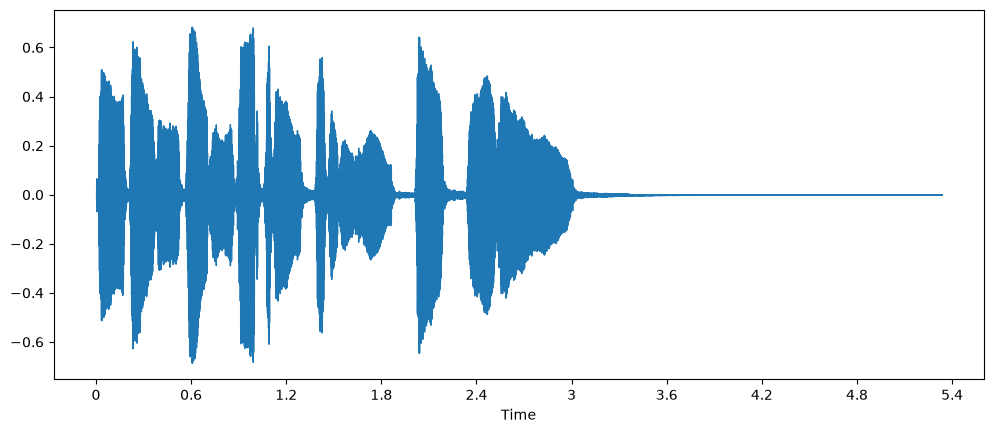

In [4]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

array, sampling_rate = librosa.load(librosa.ex("trumpet"))

plt.figure().set_figwidth(12)
librosa.display.waveshow(array, sr=sampling_rate)
plt.show()

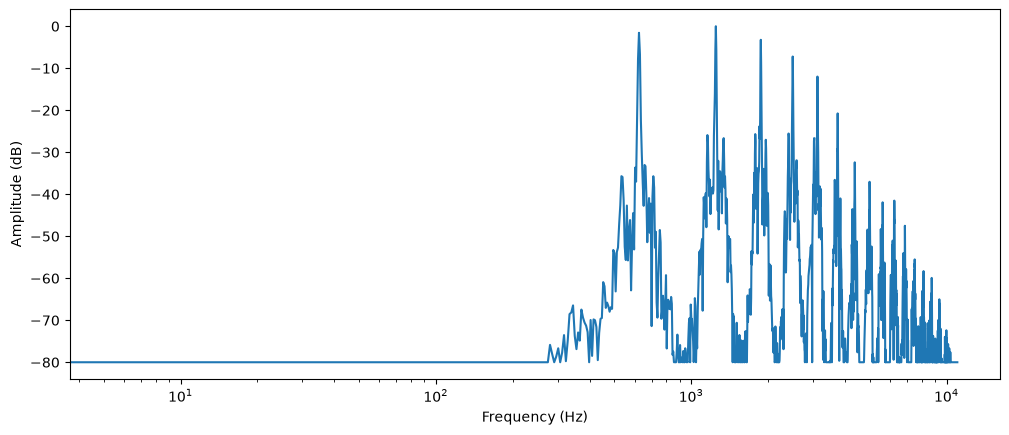

In [8]:
import numpy as np

dft_input = array[:4096]

window = np.hanning(len(dft_input))
windowed_input = dft_input * window
dft = np.fft.rfft(windowed_input)

amplitude = np.abs(dft)
amplitude_db = librosa.amplitude_to_db(amplitude, ref=np.max)

frequency = librosa.fft_frequencies(sr=sampling_rate, n_fft=len(dft_input))

plt.figure().set_figwidth(12)
plt.plot(frequency, amplitude_db)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude (dB)")
plt.xscale("log")
plt.show()

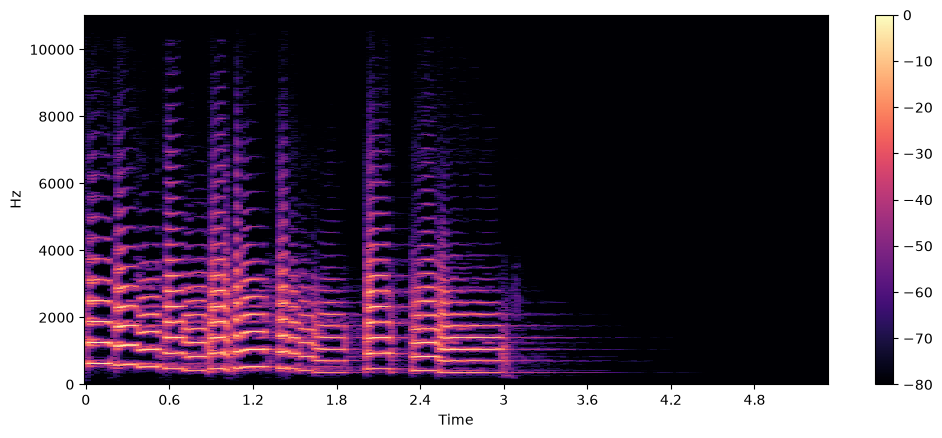

In [10]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

D = librosa.stft(array)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

plt.figure().set_figwidth(12)
librosa.display.specshow(S_db, x_axis="time", y_axis="hz")
plt.colorbar()
plt.show()

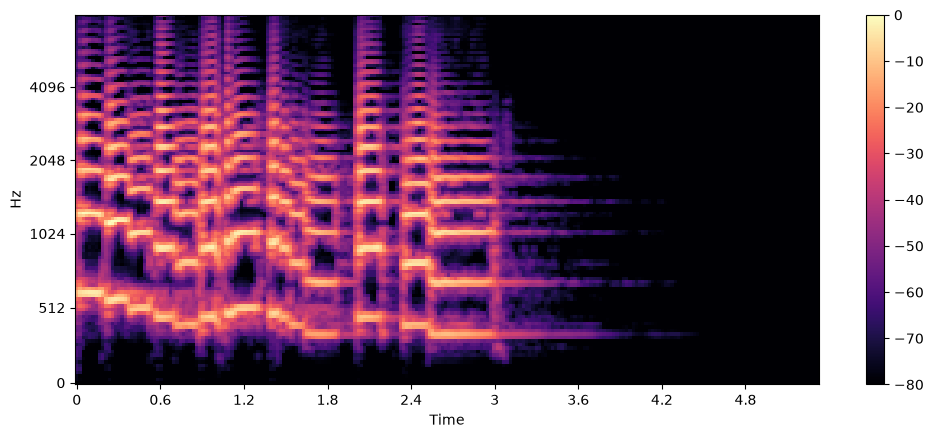

In [11]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

S = librosa.feature.melspectrogram(
    y=array,
    sr=sampling_rate,
    n_mels=128,
    fmax=8000
)
S_dB = librosa.power_to_db(S, ref=np.max)

plt.figure().set_figwidth(12)
librosa.display.specshow(
    S_dB,
    x_axis="time",
    y_axis="mel",
    sr=sampling_rate,
    fmax=8000
)
plt.colorbar()
plt.show()